In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from load_meop import MEOP
from region import Region
pfns = PlottingFns()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
from cartopy.feature import LAND
from gsw import geostrophy


In [4]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

def seasonal_anomaly(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

def get_geostrophic_currents(eta):
    lat_name = 'latitude'
    lon_name = 'longitude'
    g = 9.81
    R = 6371000.0
    omega = 7.292115e-5

    # Ensure coords are present and in degrees
    lat = eta.coords[lat_name]
    lon = eta.coords[lon_name]

    # radians
    lat_r = np.deg2rad(lat)
    lon_r = np.deg2rad(lon)

    # Build helper to take gradients along given axes using the 1D radian coords
    # Works for data with optional leading dims (e.g., time)
    def d_dcoord(da: xr.DataArray, coord: xr.DataArray, axis: int) -> xr.DataArray:
        arr = da.data
        coord_vals = coord.data
        grad = np.gradient(arr, coord_vals, axis=axis, edge_order=2)
        return xr.zeros_like(da) + grad  # keep xarray wrapper/dims

    # Axis indices for lat/lon (support datasets with extra leading dims)
    lat_axis = eta.get_axis_num(lat_name)
    lon_axis = eta.get_axis_num(lon_name)

    # Partial derivatives wrt latitude/longitude in *radians*
    deta_dphi   = d_dcoord(eta, lat_r, lat_axis)         # ∂η/∂φ
    deta_dlambda= d_dcoord(eta, lon_r, lon_axis)         # ∂η/∂λ

    # Coriolis parameter f(φ)
    f = np.sin(lat_r) * omega * 2

    # Broadcast f and cosφ to data shape
    # (xarray auto-broadcasts by coords when wrapped in DataArray with dims)
    f_da = xr.DataArray(f, dims=(lat_name,), coords={lat_name: lat})
    cosphi = xr.DataArray(np.cos(lat_r), dims=(lat_name,), coords={lat_name: lat})

    # Geostrophic components
    ug = (1.0 / R) * deta_dphi * -(g / f_da) 
    vg = (1.0 / (R * cosphi)) * deta_dlambda * (g / f_da)

    ug.name = "ug"; ug.attrs.update(units="m s-1", long_name="zonal geostrophic velocity")
    vg.name = "vg"; vg.attrs.update(units="m s-1", long_name="meridional geostrophic velocity")

    return ug, vg


In [5]:
sla_ = SLA(deg=0.25).da
elevation_ = GEBCO(coarsen_factor=40).ds.elevation
sice_ = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__
winds_ = xr.open_dataset('ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})
sam = Index(type='SAM').da.sel(time=slice(sla_.time[0],sla_.time[-1]))
data_=pd.read_csv('../data/SOI/soi_noaa.csv',header=None,index_col=0)
data=data_.to_numpy().flatten()
time=[]
for y in data_.index:
    for m in (np.arange(12)+1):
        time.append(pd.Timestamp(y,m,1).to_datetime64())
soi=xr.DataArray(data,coords={'time':time})#data={'soi':data},dims=['time'],coords={'time':time})

/tmp/ipykernel_18045/480114241.py:12: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  soi=xr.DataArray(data,coords={'time':time})#data={'soi':data},dims=['time'],coords={'time':time})


In [81]:
extent = [138,152,-68,-63]
extent_gyre = [145,150,-66.5,-65.5]
extent_ea=[60,160,-70,-60]
elevation = elevation_.sel(latitude = slice(extent_ea[2], extent_ea[3]), longitude = slice(extent_ea[0],extent_ea[1]))

In [7]:
dotds = DOT().ds
region2 = Region('ea',extent)
mdt = region2.crop_da(dotds).mean('time').rename({'ug':'u10','vg':'v10'})

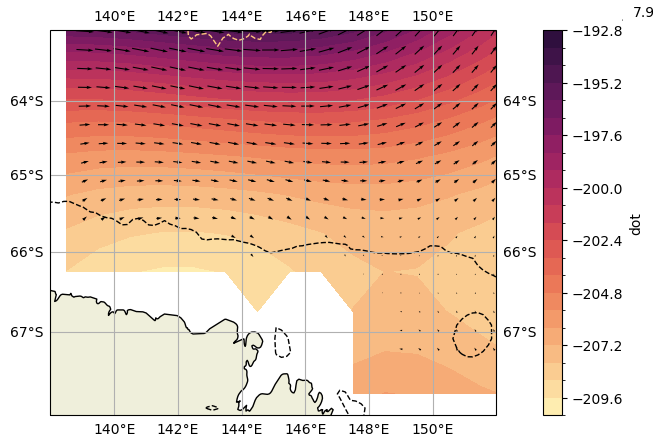

In [82]:

fig,ax = plt.subplots(figsize=(12,5),subplot_kw={'projection':ccrs.Mercator()})
mdt.dot.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.matter,transform=ccrs.PlateCarree(),levels=25)
mdt.plot.quiver(ax=ax,x='longitude',y='latitude',u='u10', v='v10',transform=ccrs.PlateCarree(),regrid_shape=25)

elevation.plot.contour(x='longitude',y='latitude',ax=ax,levels=[-1000,-4000],transform=ccrs.PlateCarree(),cmap="copper_r",vmin=-10000,vmax=0,linewidths=1,linestyles='--')

ax.set_extent(extent,crs=ccrs.PlateCarree())
ax.add_feature(LAND, edgecolor='k')
ax.gridlines(draw_labels=True)


In [83]:
region_gyre = Region('Gyre',extent_gyre,elevation=elevation)
gyre_height = region_gyre.crop_da(sla_).mean(['latitude','longitude'])

In [84]:
region = Region('Adelie',extent,elevation=elevation)#,min_elevation=-1000)
sla = region.crop_da(sla_)
sice = region.crop_da(sice_)
winds = region.crop_da(winds_)

# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

In [85]:
u,v = get_geostrophic_currents(sla)
geos = xr.Dataset({'u10':u,'v10':v})

In [86]:
dsice = sice.differentiate('time')

In [87]:
def plotc(ax,da,title,extent,vmin,vmax,cmap=cmocean.cm.balance,vector=None):
    da.plot.contourf(x='longitude',y='latitude',ax=ax,levels=40,transform=ccrs.PlateCarree(),cmap=cmap,vmin=vmin,vmax=vmax)
    if vector is not None:
        vector.plot.quiver(ax=ax,x='longitude',y='latitude',u='u10', v='v10',transform=ccrs.PlateCarree(),regrid_shape=25)
    
    elevation.plot.contour(x='longitude',y='latitude',ax=ax,levels=[-1000,-4000],transform=ccrs.PlateCarree(),cmap="copper_r",vmin=-10000,vmax=0,linewidths=1,linestyles='--')

    ax.set_title(title)
    ax.set_extent(extent,crs=ccrs.PlateCarree())
    ax.add_feature(LAND, edgecolor='k')
    ax.gridlines(draw_labels=True)


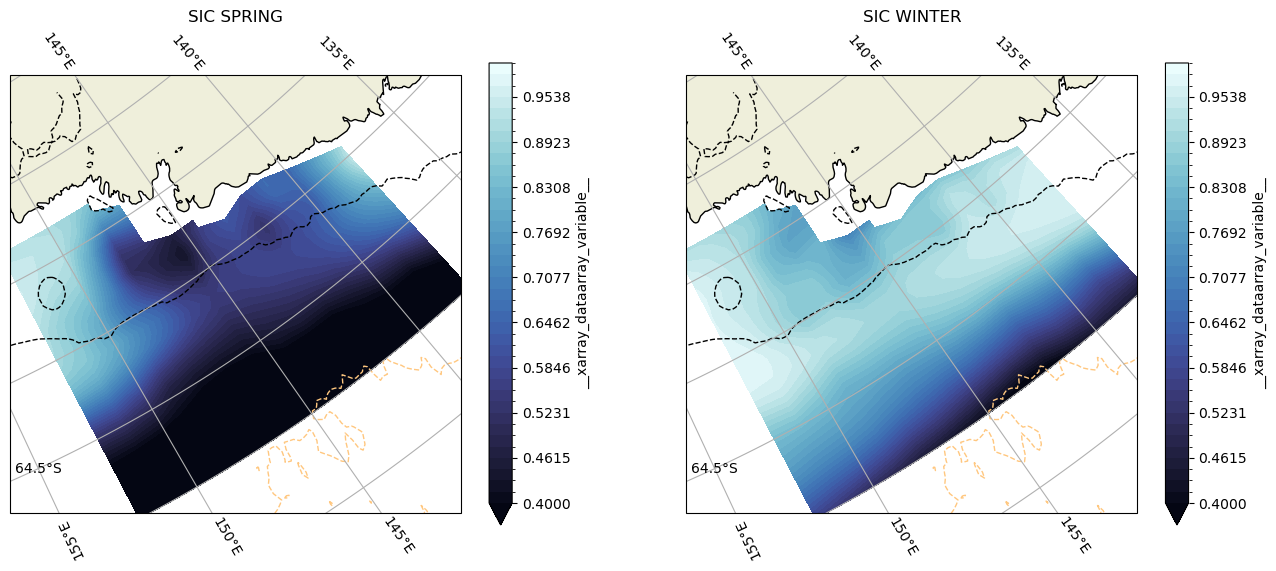

In [88]:
fig,ax = plt.subplots(1,2,figsize=(16,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
plotc(ax[0],season_split(sice)['spring'].mean('time'),'SIC SPRING',extent,vmin=0.4,vmax=1,cmap=cmocean.cm.ice)
plotc(ax[1],season_split(sice)['winter'].mean('time'),'SIC WINTER',extent,vmin=0.4,vmax=1,cmap=cmocean.cm.ice)

In [95]:
sa_sic = seasonal_anomaly(sice.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
sa_dsc = seasonal_anomaly(dsice.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
sa_sla = seasonal_anomaly(sla.interpolate_na(dim='time'))
sa_geos = seasonal_anomaly(geos.interpolate_na(dim='time'))
sa_winds = seasonal_anomaly(winds.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
sa_gyre_height = seasonal_anomaly(gyre_height)

ssn_gh = season_split(sa_gyre_height)
ssn_sla = season_split(sa_sla)
ssn_geos = season_split(sa_geos)
ssn_sic = season_split(sa_sic)
ssn_dsc = season_split(sa_dsc)
ssn_winds = season_split(sa_winds)

In [ ]:
# find top & bottom 10% of sla and sic
def get_topbot(idx,frac=0.1):
    sla_bq = idx.quantile(frac,dim='time')
    sla_tq = idx.quantile(1-frac,dim='time')
    botboo = idx <= sla_bq
    topboo = idx >= sla_tq
    top = lambda da, s=0: da.where(topboo.shift({'time':s},0),drop=True).mean('time')
    bot = lambda da, s=0: da.where(botboo.shift({'time':s},0),drop=True).mean('time')
    return topboo, botboo, top, bot

In [91]:
def run_for_idx(idx,frac,da,da_vector,da_title):  
    perc=int(frac*100)
    topboo, botboo, top, bot = get_topbot(idx,frac)

    fig = plt.figure(figsize=(14,8))
    gs = fig.add_gridspec(4,2)

    ax = fig.add_subplot(gs[0, :])

    ax.plot(idx.time,idx,color='olive',label='SLA')
    ax.plot(idx.time,np.zeros_like(idx),color='#373e02')

    # highlight regions of positive and negative index
    ax.fill_between(idx.time, 0,12, where=topboo, alpha=0.4, facecolor='darkkhaki',label='TOP/BOTTOM {}%'.format(perc))
    ax.fill_between(idx.time,-12,0, where=botboo, alpha=0.4, facecolor='darkkhaki')

    ax.set_ylim([-12,12])
    ax.set_ylabel('gyre height')
    ax.legend(loc='best')
    ax.set_title('(a)',loc='left')
    ax.grid()

    ax = fig.add_subplot(gs[1:,0],projection=ccrs.Mercator())
    plotc(ax,top(da),'{} top {}%'.format(da_title,perc),extent,-6,9,vector=top(da_vector))
    ax = fig.add_subplot(gs[1:,1],projection=ccrs.Mercator())
    plotc(ax,bot(da),'{} bottom {}%'.format(da_title,perc),extent,-6,9,vector=bot(da_vector))

    plt.tight_layout()

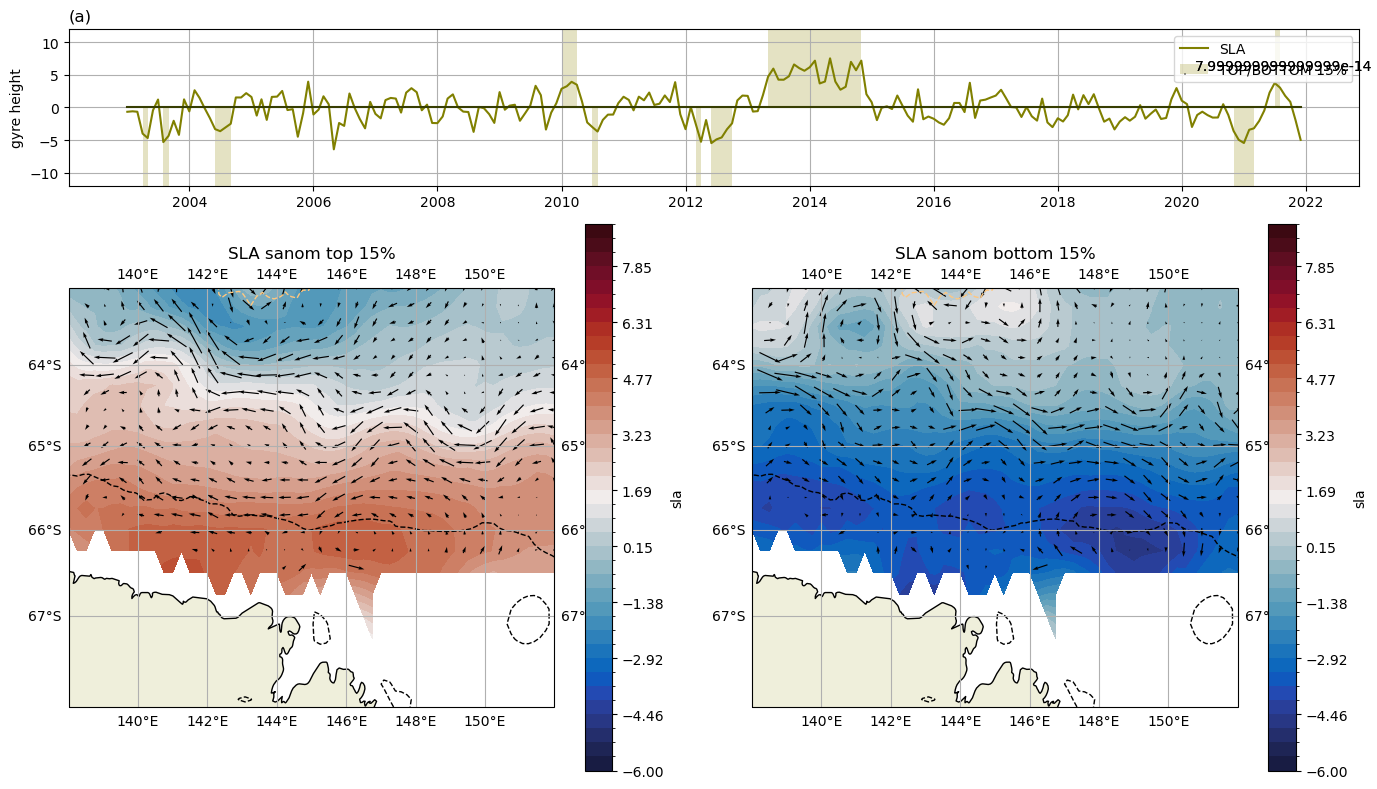

In [92]:
idx=sa_gyre_height
run_for_idx(sa_gyre_height,0.15,sa_sla,sa_geos,'SLA sanom')

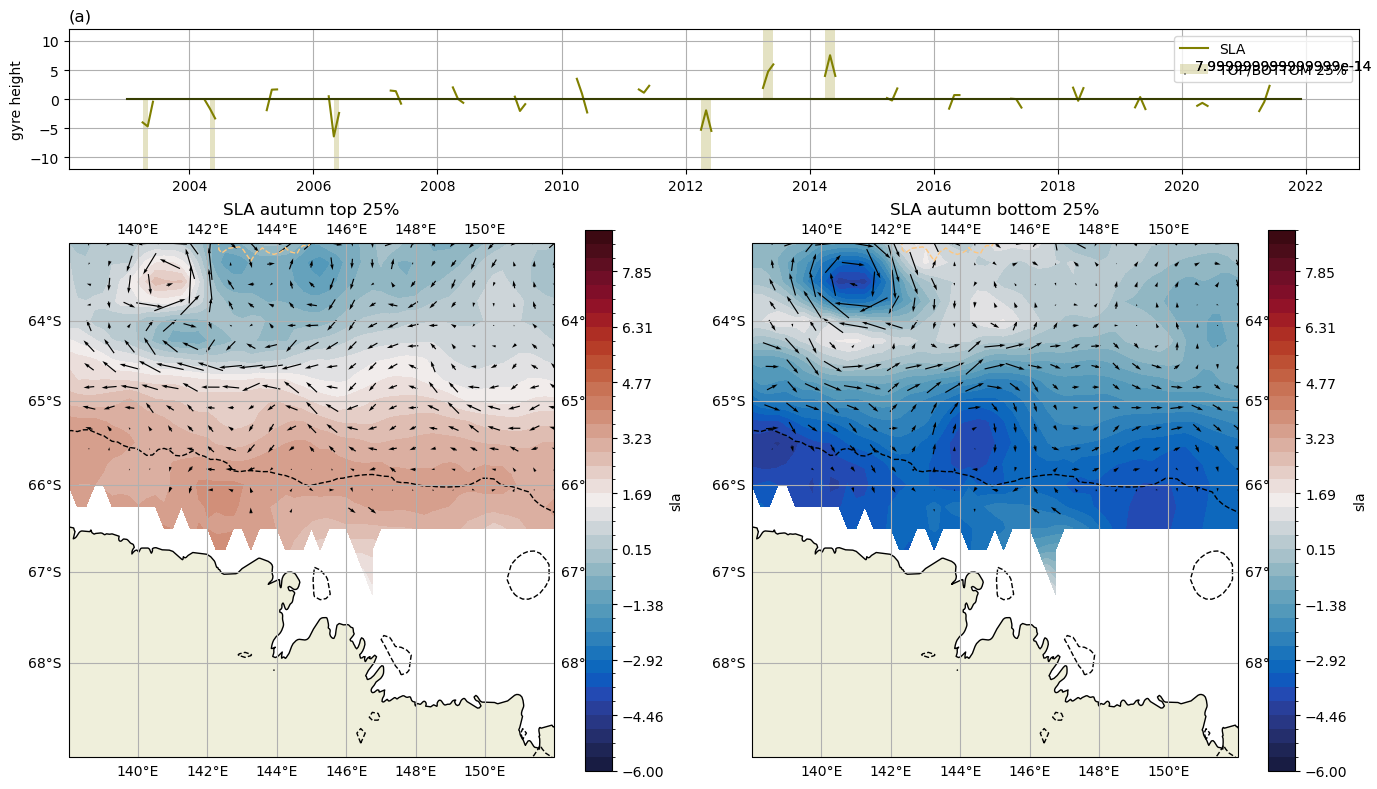

In [ ]:
s = 'autumn'
run_for_idx(ssn_gh[s],0.25,ssn_sla[s],ssn_geos[s],'SLA autumn')


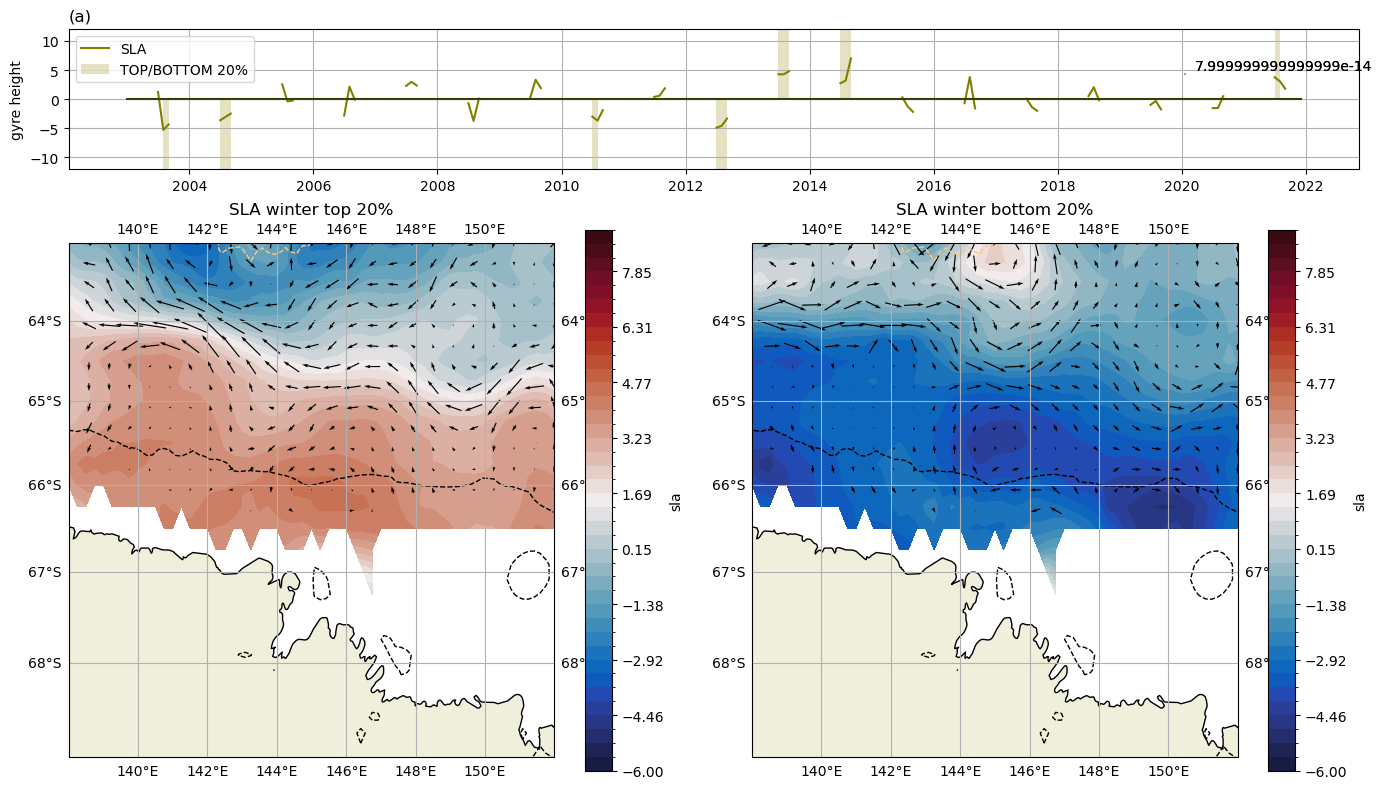

In [ ]:
s = 'winter'
run_for_idx(ssn_gh[s],0.25,ssn_sla[s],ssn_geos[s],'SLA winter')

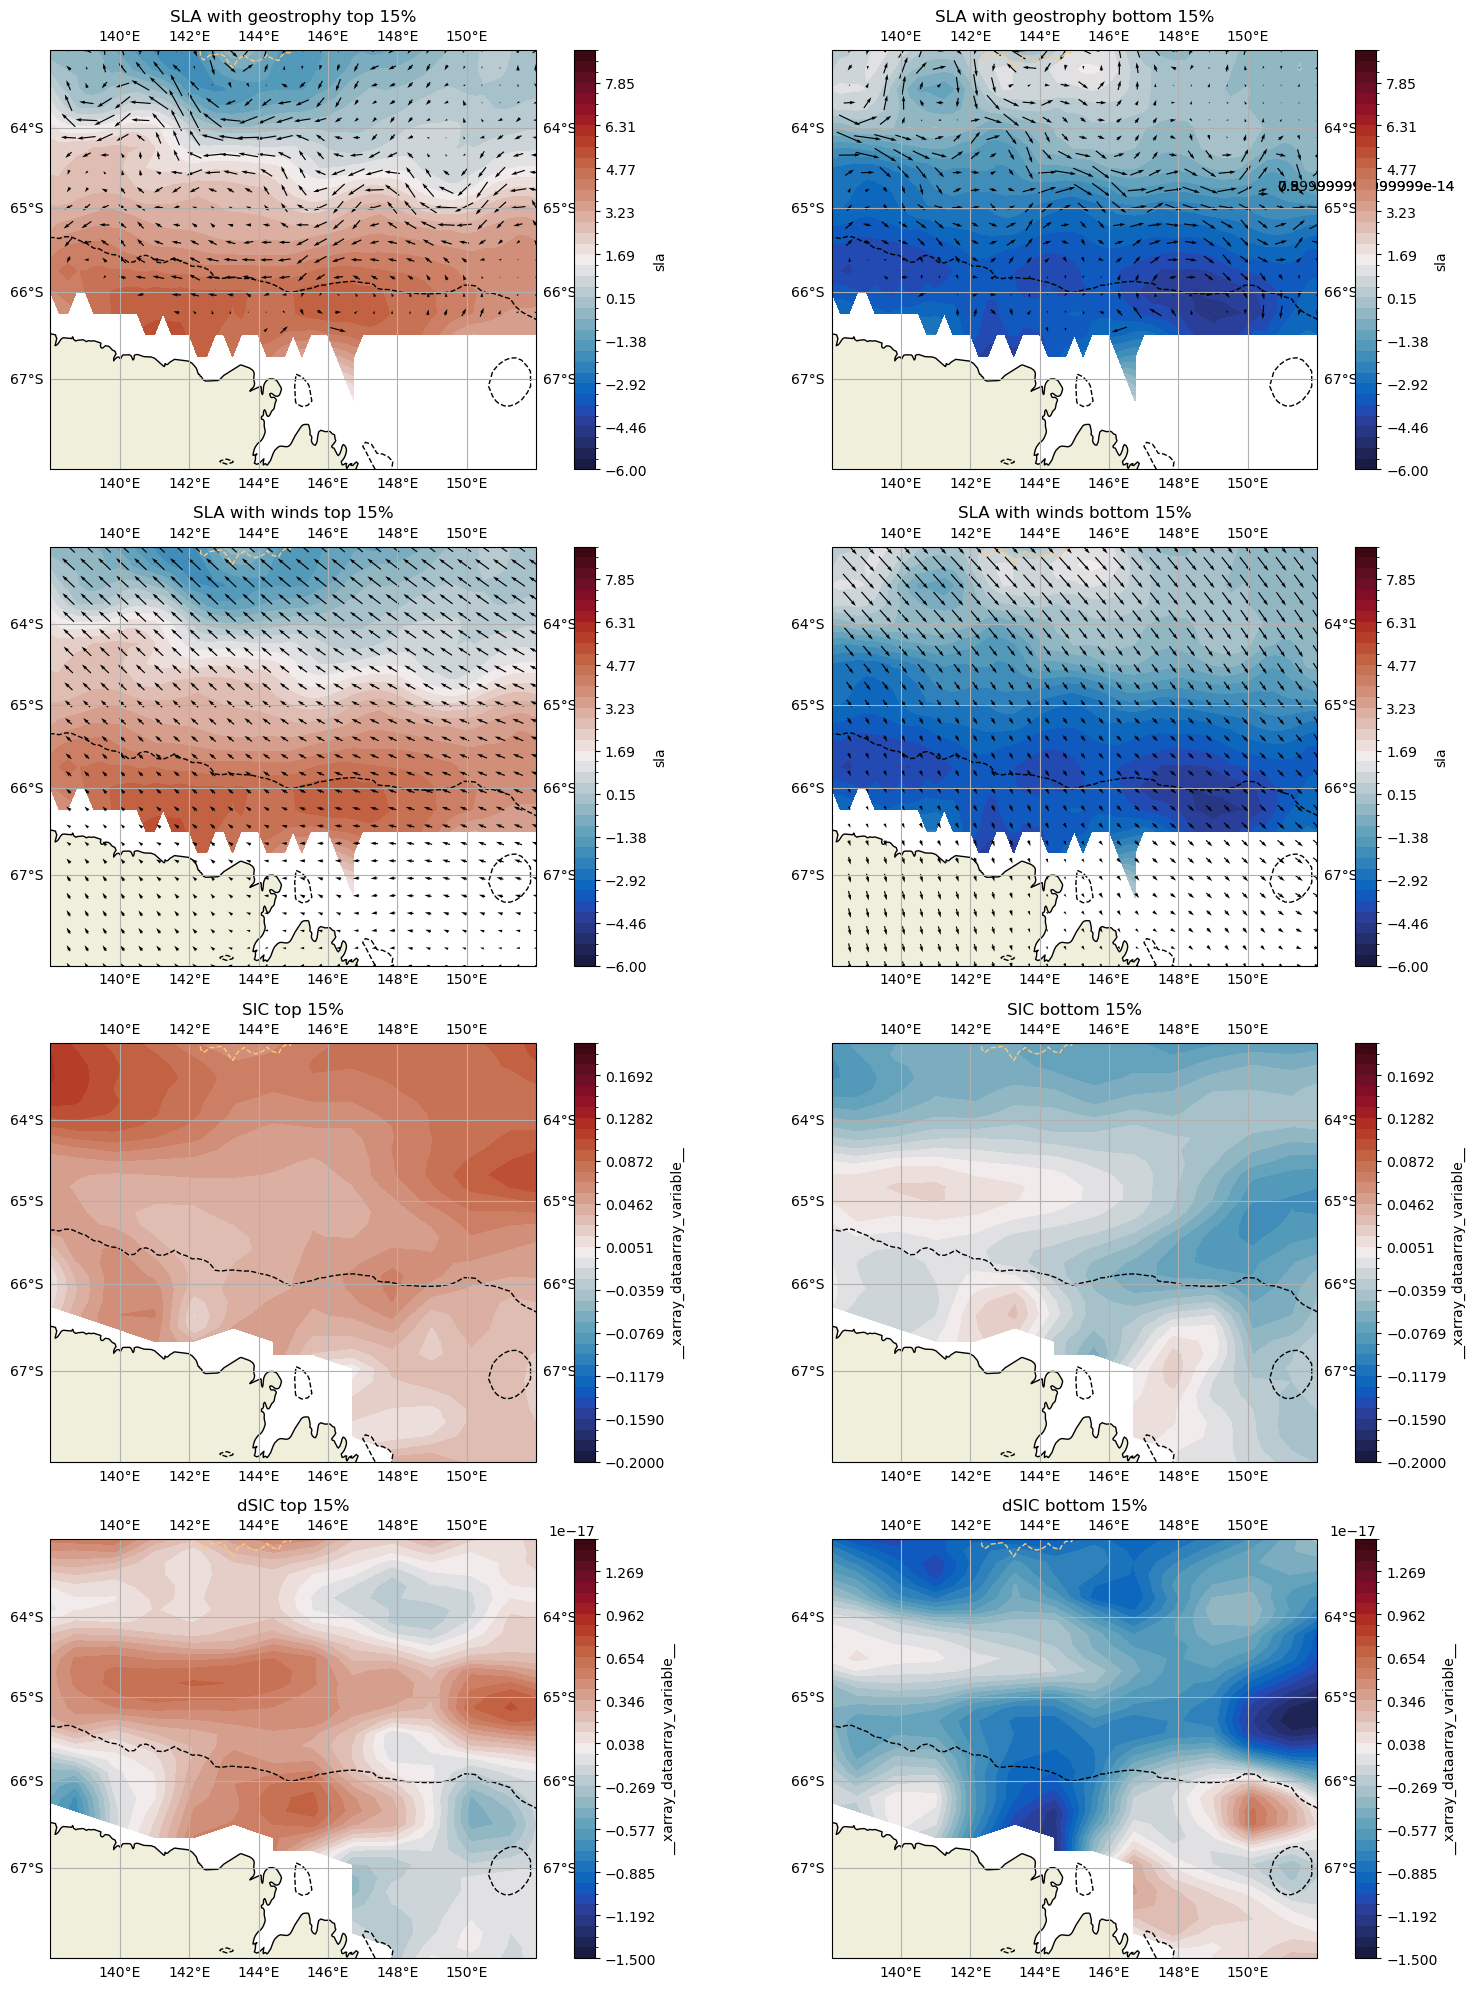

In [97]:
frac = 0.15
topboo, botboo, top, bot = get_topbot(sa_gyre_height,frac)
perc = int(frac*100)

fig,ax = plt.subplots(4,2,figsize=(16,20),subplot_kw={'projection':ccrs.Mercator()})

# sla
plotc(ax[0][0],top(sa_sla),'{} top {}%'.format('SLA with geostrophy',perc),extent,-6,9,vector=top(sa_geos))
plotc(ax[0][1],bot(sa_sla),'{} bottom {}%'.format('SLA with geostrophy',perc),extent,-6,9,vector=bot(sa_geos))

# sla
plotc(ax[1][0],top(sa_sla),'{} top {}%'.format('SLA with winds',perc),extent,-6,9,vector=top(sa_winds))
plotc(ax[1][1],bot(sa_sla),'{} bottom {}%'.format('SLA with winds',perc),extent,-6,9,vector=bot(sa_winds))

# sic
n = 0.2
plotc(ax[2][0],top(sa_sic),'{} top {}%'.format('SIC',perc),extent,-n,n)
plotc(ax[2][1],bot(sa_sic),'{} bottom {}%'.format('SIC',perc),extent,-n,n)

# dsc
n = 1.5e-17
plotc(ax[3][0],top(sa_dsc),'{} top {}%'.format('dSIC',perc),extent,-n,n)
plotc(ax[3][1],bot(sa_dsc),'{} bottom {}%'.format('dSIC',perc),extent,-n,n)

plt.tight_layout()

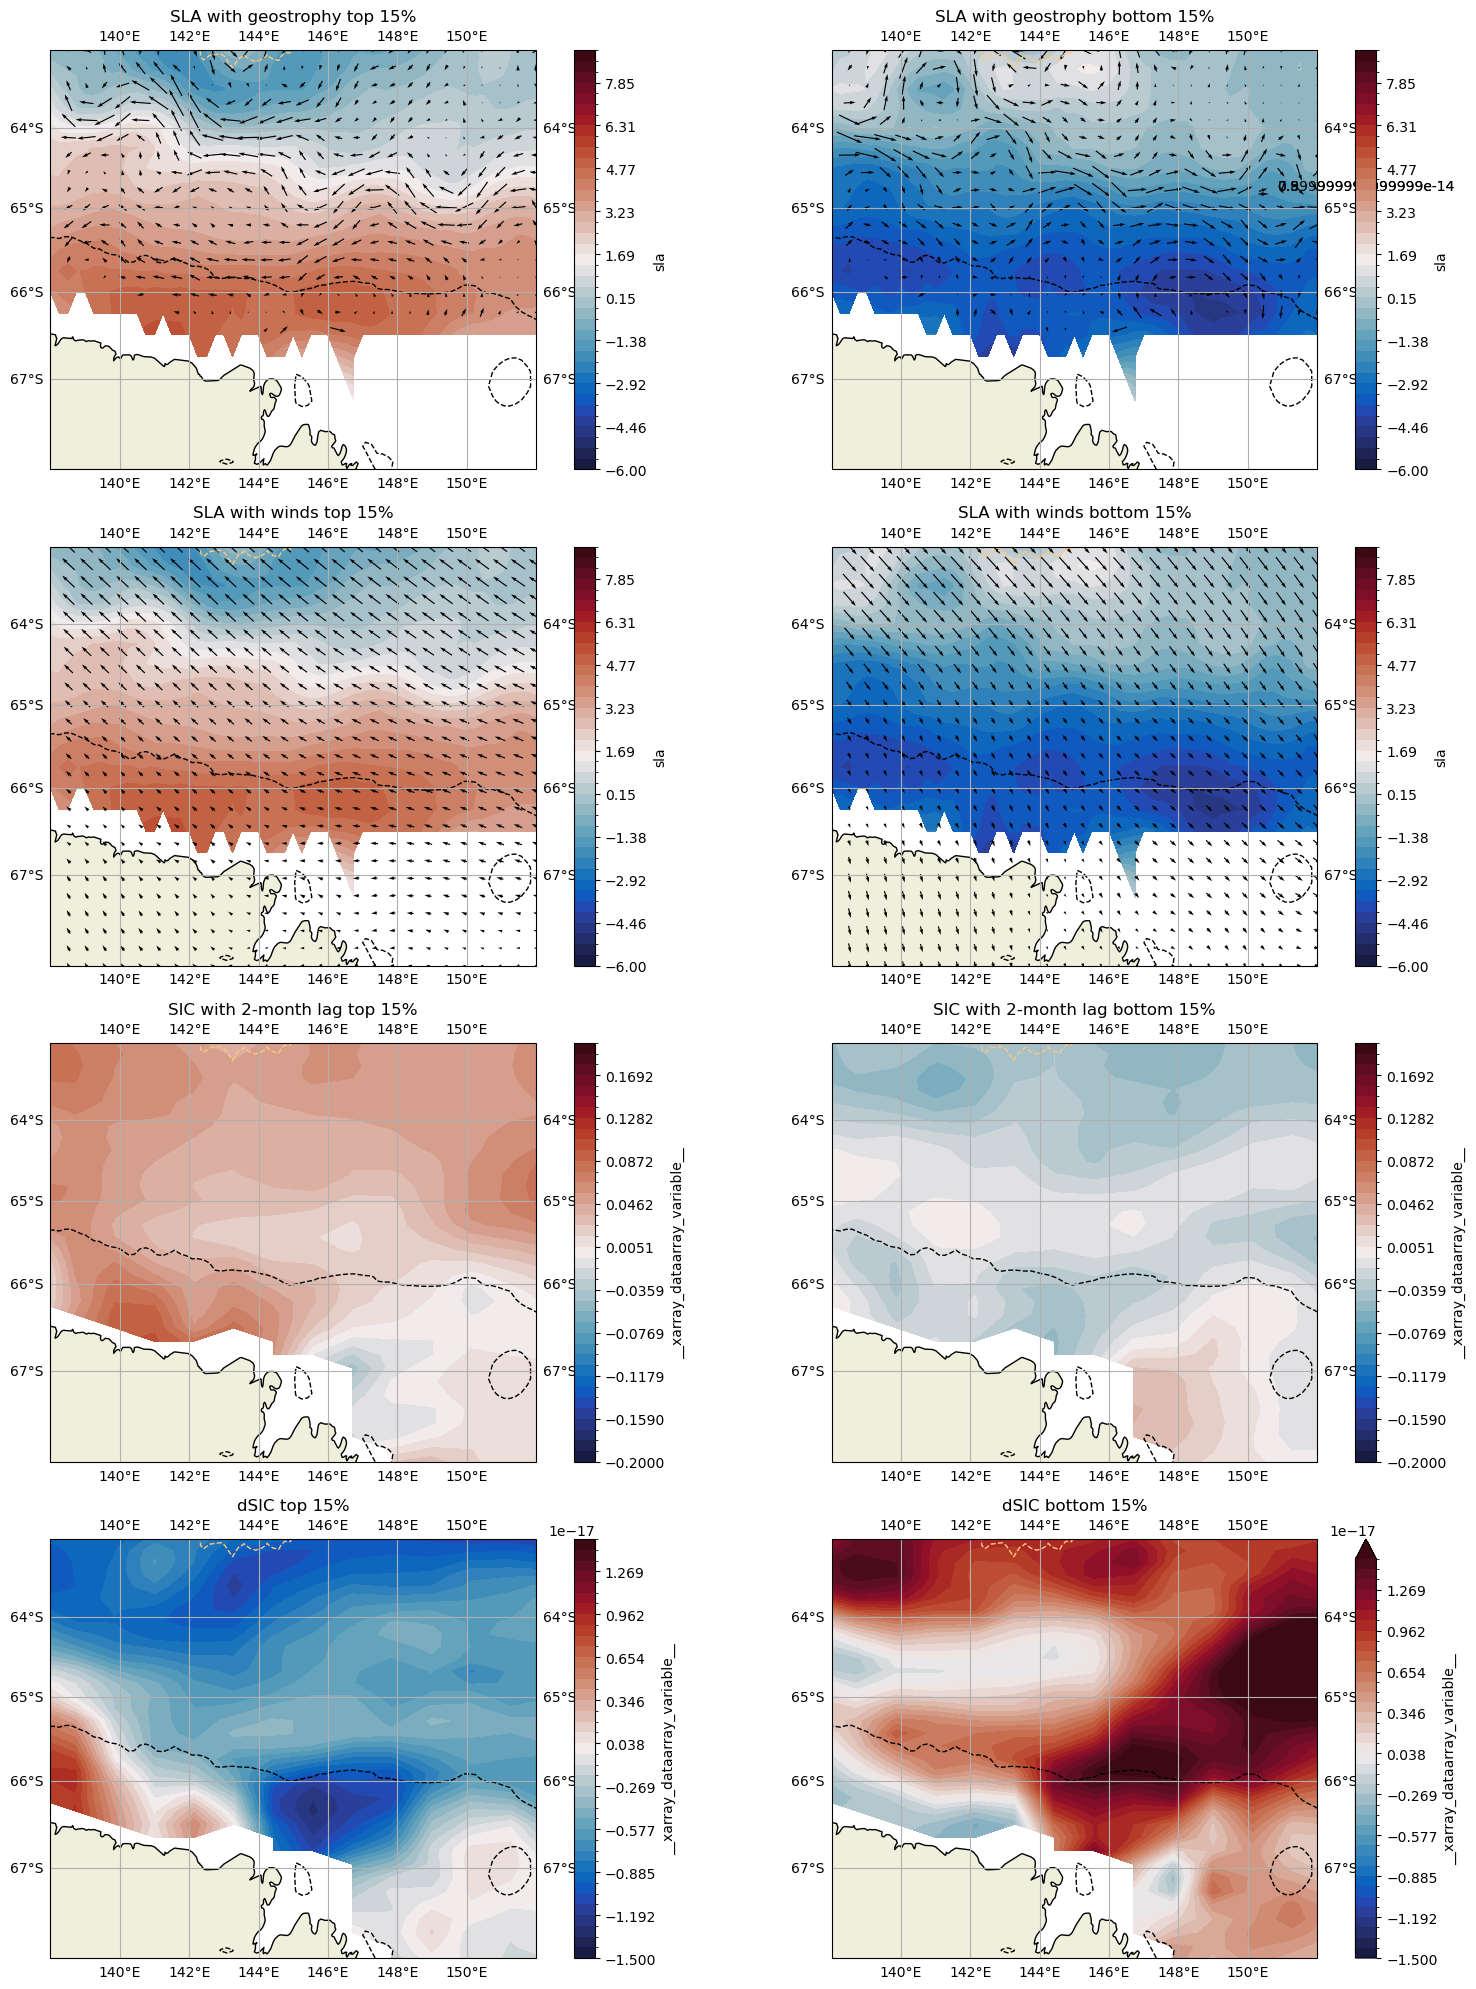

In [98]:
frac = 0.15
topboo, botboo, top, bot = get_topbot(sa_gyre_height,frac)
perc = int(frac*100)

fig,ax = plt.subplots(4,2,figsize=(16,20),subplot_kw={'projection':ccrs.Mercator()})

# sla
plotc(ax[0][0],top(sa_sla),'{} top {}%'.format('SLA with geostrophy',perc),extent,-6,9,vector=top(sa_geos))
plotc(ax[0][1],bot(sa_sla),'{} bottom {}%'.format('SLA with geostrophy',perc),extent,-6,9,vector=bot(sa_geos))

# sla
plotc(ax[1][0],top(sa_sla),'{} top {}%'.format('SLA with winds',perc),extent,-6,9,vector=top(sa_winds))
plotc(ax[1][1],bot(sa_sla),'{} bottom {}%'.format('SLA with winds',perc),extent,-6,9,vector=bot(sa_winds))

lag = 2
# sic
n = 0.2
ttl = 'SIC with {}-month lag'.format(lag)
plotc(ax[2][0],top(sa_sic,2),'{} top {}%'.format(ttl,perc),extent,-n,n)
plotc(ax[2][1],bot(sa_sic,2),'{} bottom {}%'.format(ttl,perc),extent,-n,n)

# dsc
n = 1.5e-17
ttl = 'dSIC with {}-month lag'.format(lag)
plotc(ax[3][0],top(sa_dsc,2),'{} top {}%'.format('dSIC',perc),extent,-n,n)
plotc(ax[3][1],bot(sa_dsc,2),'{} bottom {}%'.format('dSIC',perc),extent,-n,n)

plt.tight_layout()

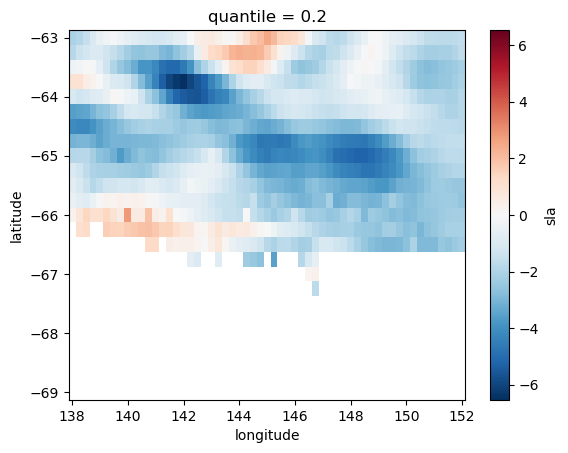

In [27]:
lonboo = da_sla.longitude < 147
latboo = da_sla.latitude > -66.6
bot(da_sla).where(lonboo | latboo,drop=True).plot()

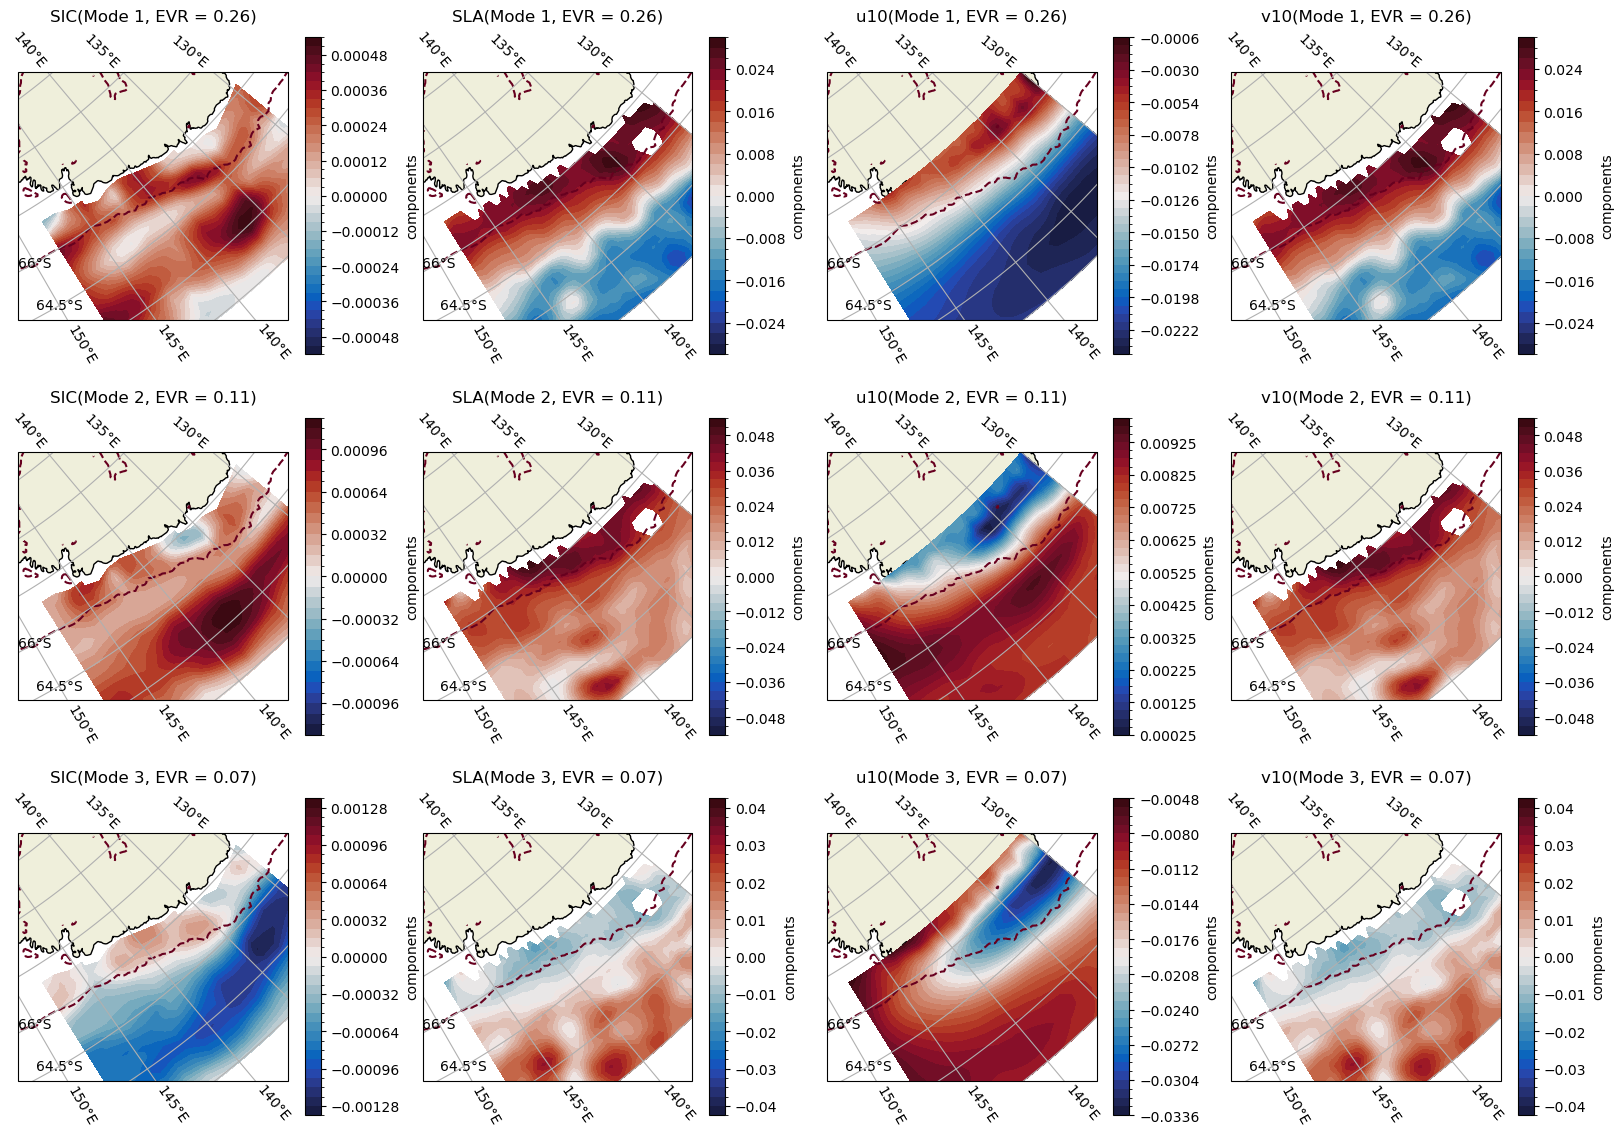

In [ ]:






fig,axs = plt.subplots(3,4,figsize=(20,14),subplot_kw={'projection':ccrs.SouthPolarStereo()})

# plot maps
def plot_component(ax,component,title,mode):
    comp=component.sel(mode=mode)
    evr_=evr.sel(mode=mode).item()
    comp.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40)
    ax.set_extent(extent,crs=ccrs.PlateCarree())
    ax.add_feature(LAND, edgecolor='k')
    ax.gridlines(draw_labels=True)
    elevation.plot.contour(x='longitude',y='latitude',ax=ax,transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')
    ax.set_title(title + '(Mode {0}, EVR = {1})'.format(mode,round(evr_,2)))

for i, row in enumerate(axs) :
    plot_component(row[0],components[0],'SIC',mode=i+1)
    plot_component(row[1],components[1],'SLA',mode=i+1)
    plot_component(row[2],components[2],'u10',mode=i+1)
    plot_component(row[3],components[1],'v10',mode=i+1)



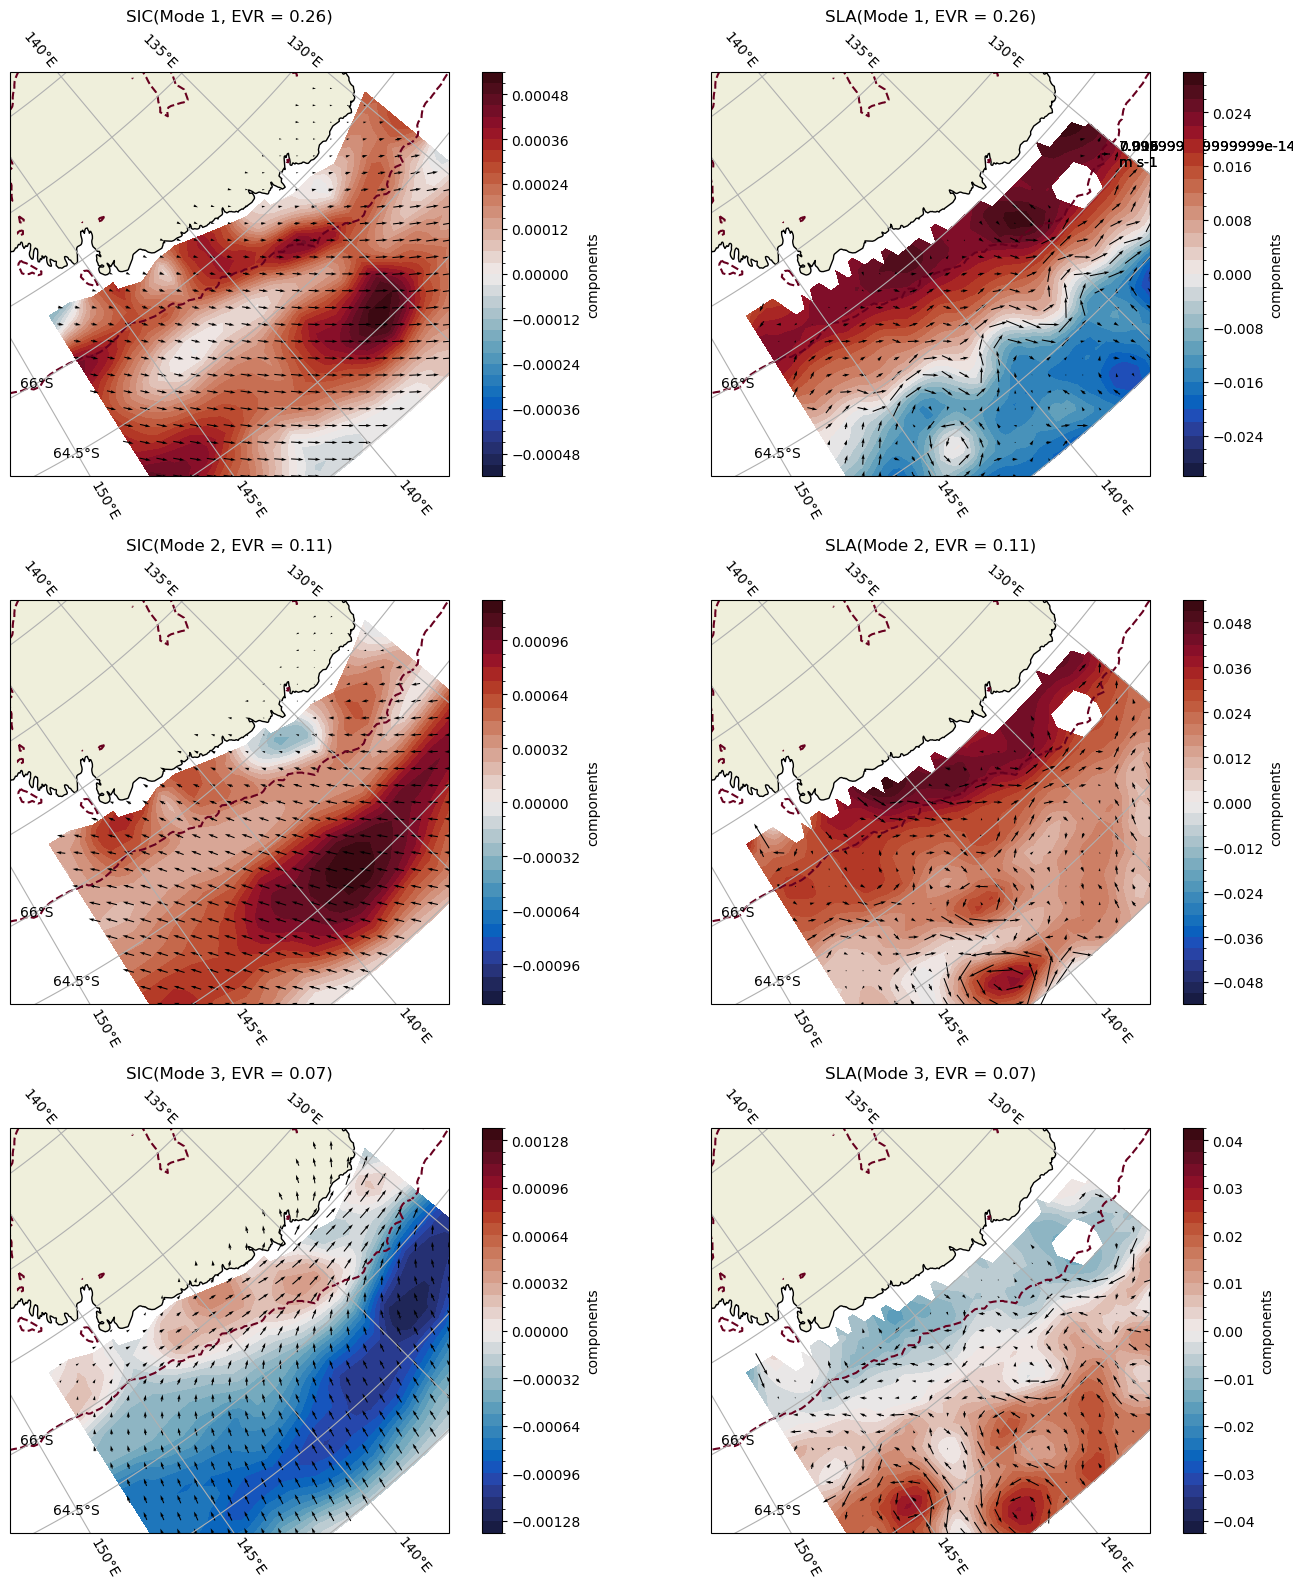

In [16]:
#plot with geostrophic currents
fig,axs = plt.subplots(3,2,figsize=(14,16),subplot_kw={'projection':ccrs.SouthPolarStereo()})

# plot maps
def plot_component(ax,component,title,mode,u,v):
    comp=component.sel(mode=mode)
    evr_=evr.sel(mode=mode).item()
    comp.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40)
    ax.set_extent(extent,crs=ccrs.PlateCarree())
    ax.add_feature(LAND, edgecolor='k')
    ax.gridlines(draw_labels=True)
    elevation.plot.contour(x='longitude',y='latitude',ax=ax,transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')
    ds =xr.Dataset({'u10':u,'v10':v})
    ds.plot.quiver(ax=ax,x='longitude',y='latitude',u='u10', v='v10',transform=ccrs.PlateCarree(),regrid_shape=25)
    ax.set_title(title + '(Mode {0}, EVR = {1})'.format(mode,round(evr_,2)))

for i, row in enumerate(axs) :
    mode = i + 1
    ug, vg = get_geostrophic_currents(components[1].sel(mode=mode))
    plot_component(row[0],components[0],'SIC',mode=i+1,u=components[2].sel(mode=mode),v=components[3].sel(mode=mode))
    plot_component(row[1],components[1],'SLA',mode=i+1,u=ug,v=vg)


plt.tight_layout()


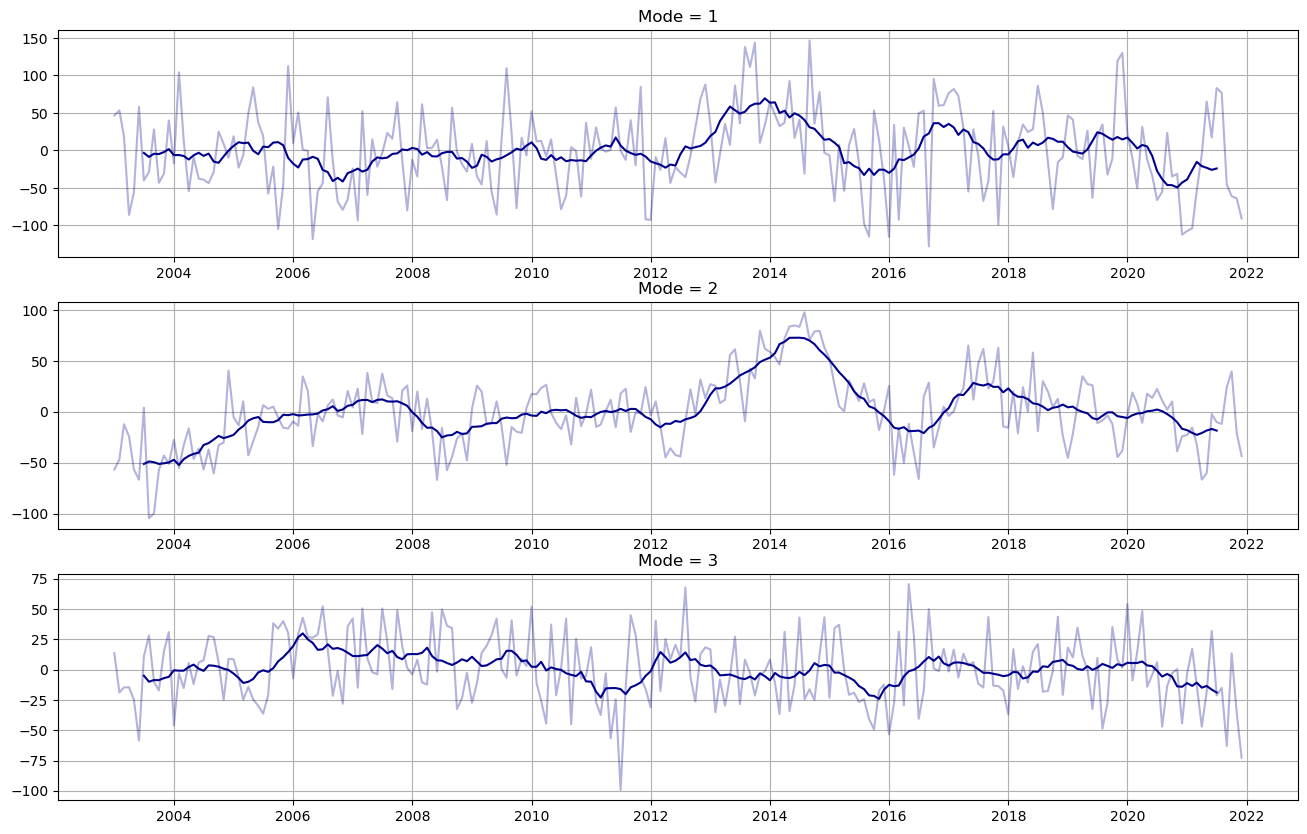

In [19]:
fig,axs = plt.subplots(3,1,figsize=(16,10))
for i in np.arange(3):
    axs[i].plot(scores.time,scores.sel(mode=i+1),c='darkblue',alpha=0.3)
    l1= axs[i].plot(scores.time,scores.sel(mode=i+1).rolling({'time':12},center=True).mean(),c='darkblue',label='scores')
    axs[i].set_title('Mode = {}'.format(i+1))
    axs[i].grid()
    #if not i==2:
    #a2=axs[i].twinx()
    #a2.plot(sam.time,sam,c='r',alpha=0.3)
    #l2 = a2.plot(sam.time,sam.rolling({'time':12},center=True).mean(),c='r',label='SAM index')
    #axs[i].legend(l1+l2,['scores','SAM idx'],loc='best')


In [18]:
del scores.attrs['solver_kwargs']

In [121]:
scores.sel(mode=1).to_netcdf('scores_eof1.nc')
scores.sel(mode=2).to_netcdf('scores_eof2.nc')
scores.sel(mode=3).to_netcdf('scores_eof3.nc')


In [43]:
mca = xf.cross.MCA(n_modes=20, standardize=False, use_coslat=True)
mca.fit(da_sic,da_u10, dim="time")

In [32]:
singular_vectors = mca.components()
scores = mca.scores()
hom_pats, pvals_hom = mca.homogeneous_patterns()
het_pats, pvals_het = mca.heterogeneous_patterns()

In [33]:
hom_mask = [values < 0.05 for values in pvals_hom]
het_mask = [values < 0.05 for values in pvals_het]

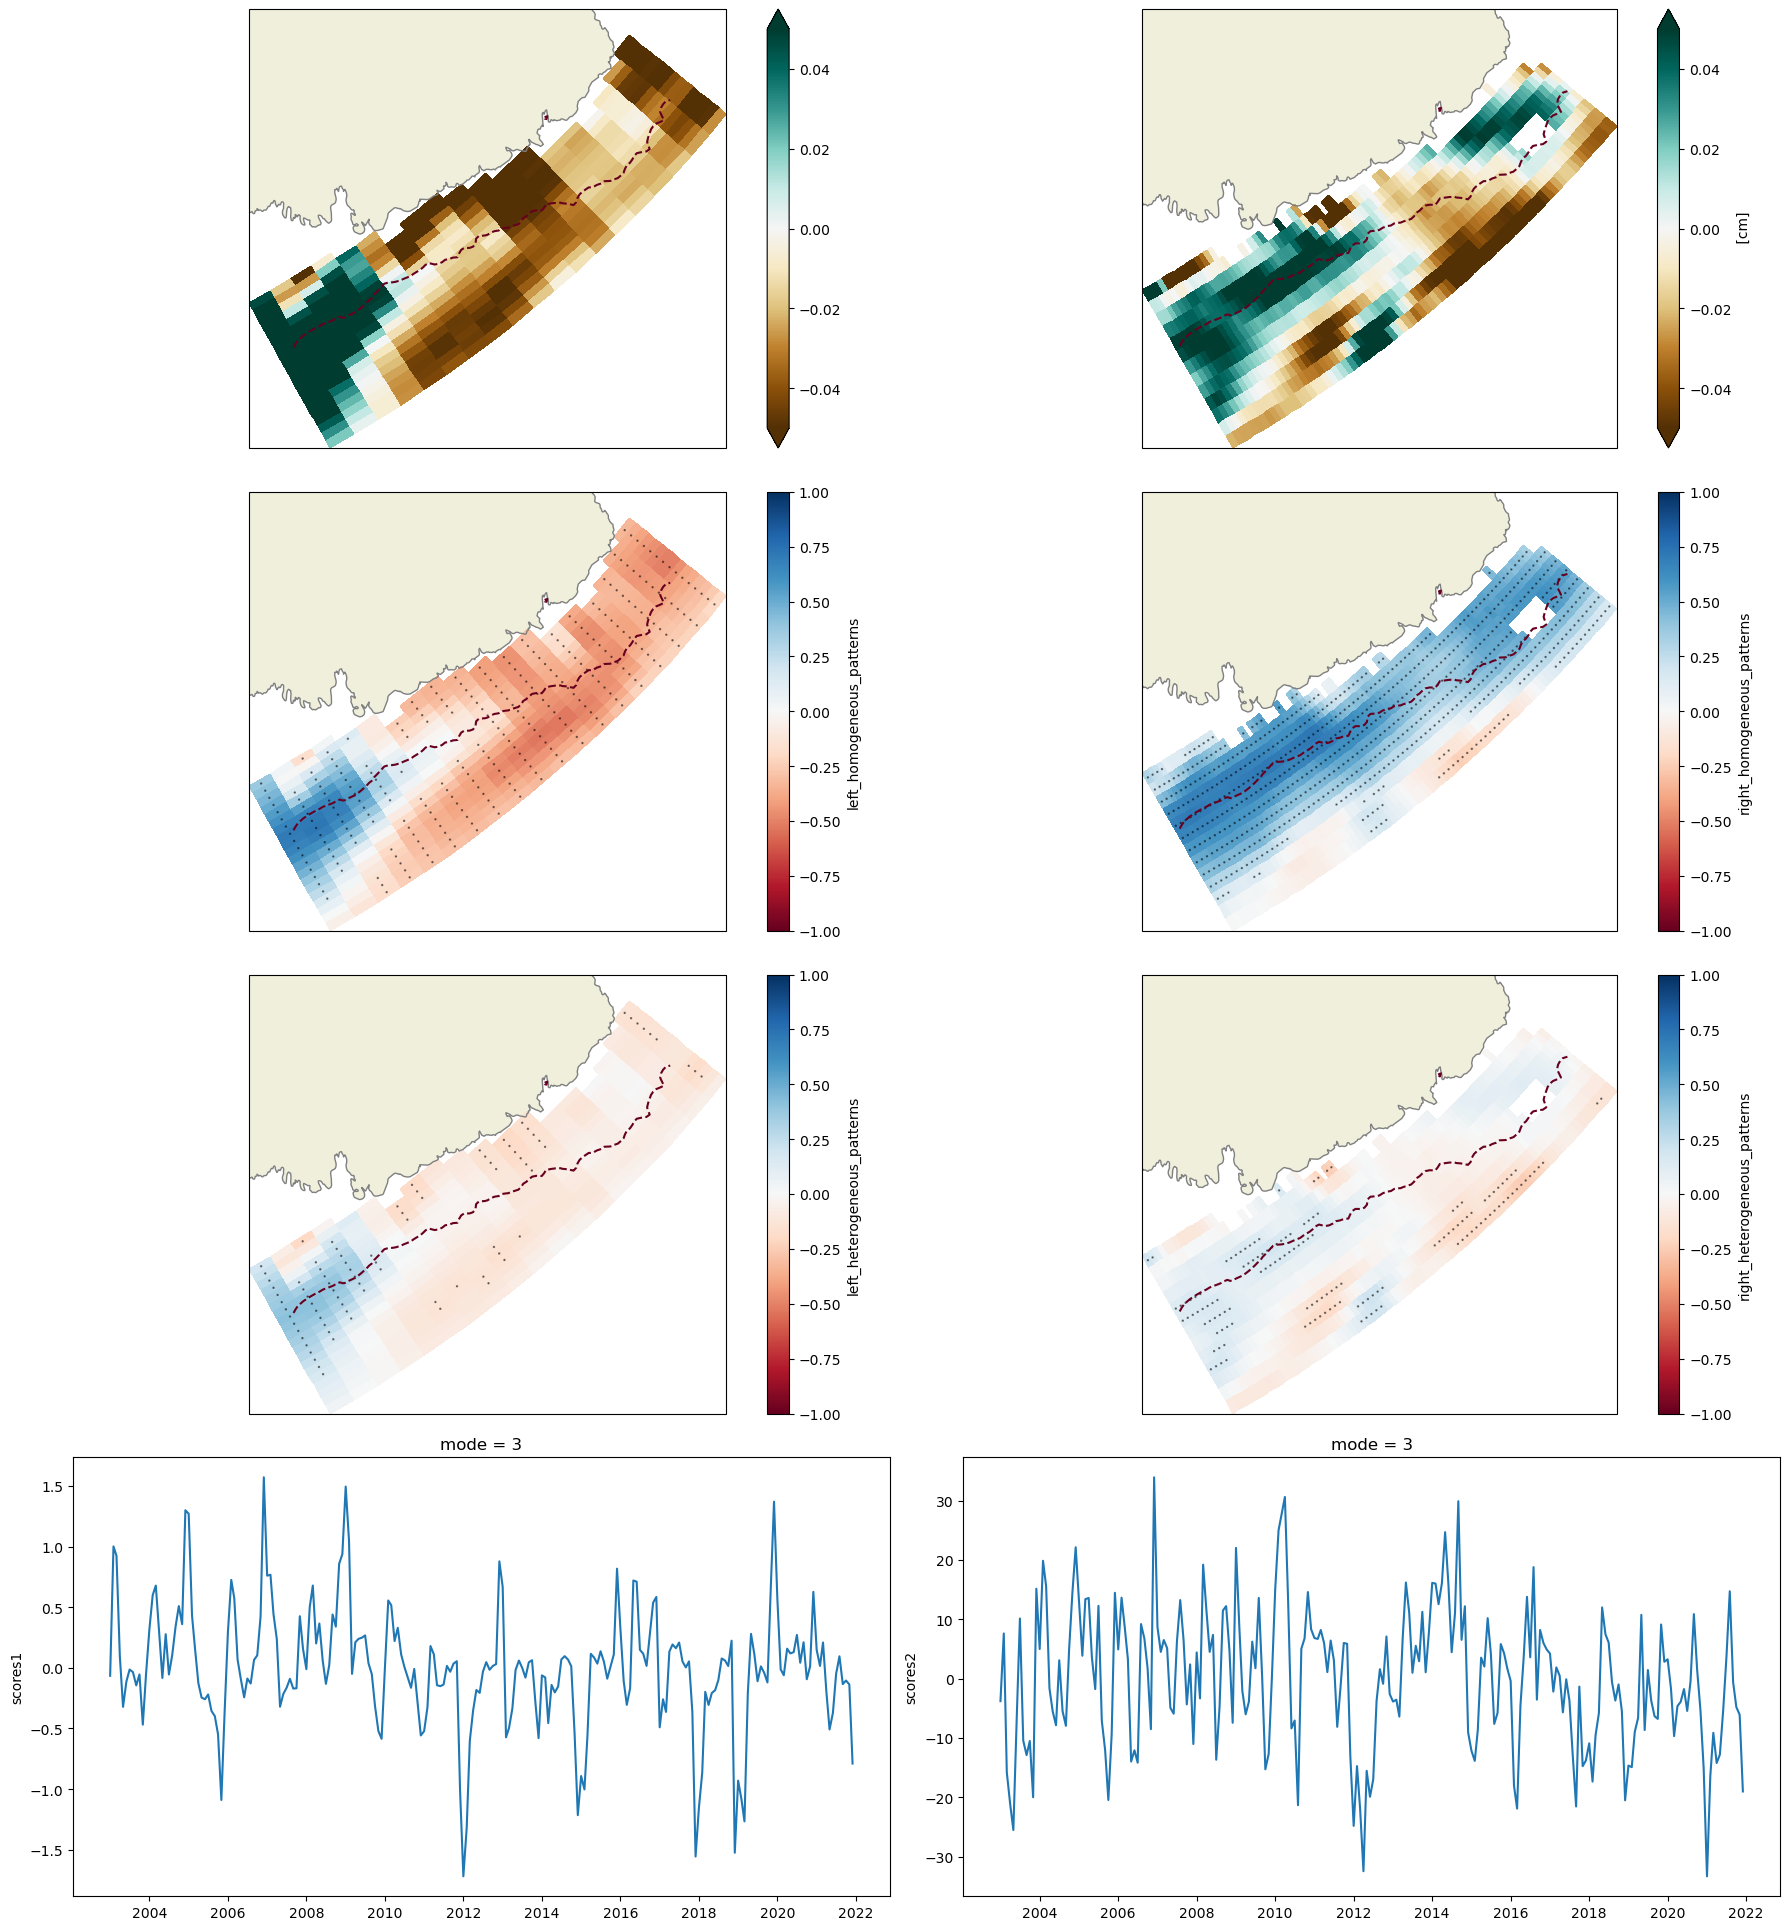

In [36]:
from matplotlib.gridspec import GridSpec

plot_isobath = lambda ax: elevation.plot.contour(x='longitude',y='latitude',ax=ax,transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')
lonlats = [
    np.meshgrid(pvals_hom[0].longitude.values, pvals_hom[0].latitude.values),
    np.meshgrid(pvals_hom[1].longitude.values, pvals_hom[1].latitude.values),
]
proj = [
    # Orthographic(central_latitude=30, central_longitude=-120),
    # Orthographic(central_latitude=30, central_longitude=-60),
    ccrs.SouthPolarStereo(),
    ccrs.SouthPolarStereo()
]
kwargs1 = {"cmap": "BrBG", "vmin": -0.05, "vmax": 0.05, "transform": ccrs.PlateCarree()}
kwargs2 = {"cmap": "RdBu", "vmin": -1, "vmax": 1, "transform": ccrs.PlateCarree()}

mode = 3

fig = plt.figure(figsize=(18,24))
gs = GridSpec(5, 2)
ax1 = [fig.add_subplot(gs[0, i], projection=proj[i]) for i in range(2)]
ax2 = [fig.add_subplot(gs[1, i], projection=proj[i]) for i in range(2)]
ax3 = [fig.add_subplot(gs[2, i], projection=proj[i]) for i in range(2)]
ax4 = [fig.add_subplot(gs[3, i]) for i in range(2)]

for i, a in enumerate(ax1):
    singular_vectors[i].sel(mode=mode).plot(ax=a, **kwargs1)

for i, a in enumerate(ax2):
    hom_pats[i].sel(mode=mode).plot(ax=a, **kwargs2)
    a.scatter(
        lonlats[i][0],
        lonlats[i][1],
        hom_mask[i].sel(mode=mode).values * 0.5,
        color="k",
        alpha=0.5,
        transform=ccrs.PlateCarree(),
    )

for i, a in enumerate(ax3):
    het_pats[i].sel(mode=mode).plot(ax=a, **kwargs2)
    a.scatter(
        lonlats[i][0],
        lonlats[i][1],
        het_mask[i].sel(mode=mode).values * 0.5,
        color="k",
        alpha=0.5,
        transform=ccrs.PlateCarree(),
    )

for i, a in enumerate(ax4):
    scores[i].sel(mode=mode).plot(ax=a)
    a.set_xlabel("")


for a in np.ravel([ax1, ax2, ax3]):
    a.coastlines(color=".5")
    a.add_feature(LAND)
    plot_isobath(a)

plt.tight_layout()
